# W3 Data Transformation


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans

In [3]:
df= pd.read_csv('data/college.csv')
df.head()

,id,name,city,state,region,highest_degree,control,gender,admission_rate,sat_avg,undergrads,tuition,faculty_salary_avg,loan_default_rate,median_debt,lon,lat
0,102669,Alaska Pacific University,Anchorage,AK,West,Graduate,Private,CoEd,0.4207,1054,275,19610,5804,0.077,23250.0,-149.900278,61.218056
1,101648,Marion Military Institute,Marion,AL,South,Associate,Public,CoEd,0.6139,1055,433,8778,5916,0.136,11500.0,-87.319165,32.632354
2,100830,Auburn University at Montgomery,Montgomery,AL,South,Graduate,Public,CoEd,0.8017,1009,4304,9080,7255,0.106,21335.0,-86.299969,32.366805
3,101879,University of North Alabama,Florence,AL,South,Graduate,Public,CoEd,0.6788,1029,5485,7412,7424,0.111,21500.0,-87.677251,34.799810
4,100858,Auburn University,Auburn,AL,South,Graduate,Public,CoEd,0.8347,1215,20514,10200,9487,0.045,21831.0,-85.480782,32.609857


# EDA

In [4]:
# convert data. types
list=['gender', 'region', 'highest_degree', 'control', ]
df[list] = df[list].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1269 entries, 0 to 1268
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  1269 non-null   int64   
 1   name                1269 non-null   object  
 2   city                1269 non-null   object  
 3   state               1269 non-null   object  
 4   region              1269 non-null   category
 5   highest_degree      1269 non-null   category
 6   control             1269 non-null   category
 7   gender              1269 non-null   category
 8   admission_rate      1269 non-null   float64 
 9   sat_avg             1269 non-null   int64   
 10  undergrads          1269 non-null   int64   
 11  tuition             1269 non-null   int64   
 12  faculty_salary_avg  1269 non-null   int64   
 13  loan_default_rate   1267 non-null   float64 
 14  median_debt         1269 non-null   float64 
 15  lon                 1269 non-null   fl

In [5]:
#identify missing values 
df.isnull().sum()

id                    0
name                  0
city                  0
state                 0
region                0
highest_degree        0
control               0
gender                0
admission_rate        0
sat_avg               0
undergrads            0
tuition               0
faculty_salary_avg    0
loan_default_rate     2
median_debt           0
lon                   0
lat                   0
dtype: int64

In [6]:
#replace missing value in numerical var with mean
df['loan_default_rate'] = df['loan_default_rate'].fillna(df['loan_default_rate'].mean())
df.isnull().sum()
df.head()

,id,name,city,state,region,highest_degree,control,gender,admission_rate,sat_avg,undergrads,tuition,faculty_salary_avg,loan_default_rate,median_debt,lon,lat
0,102669,Alaska Pacific University,Anchorage,AK,West,Graduate,Private,CoEd,0.4207,1054,275,19610,5804,0.077,23250.0,-149.900278,61.218056
1,101648,Marion Military Institute,Marion,AL,South,Associate,Public,CoEd,0.6139,1055,433,8778,5916,0.136,11500.0,-87.319165,32.632354
2,100830,Auburn University at Montgomery,Montgomery,AL,South,Graduate,Public,CoEd,0.8017,1009,4304,9080,7255,0.106,21335.0,-86.299969,32.366805
3,101879,University of North Alabama,Florence,AL,South,Graduate,Public,CoEd,0.6788,1029,5485,7412,7424,0.111,21500.0,-87.677251,34.799810
4,100858,Auburn University,Auburn,AL,South,Graduate,Public,CoEd,0.8347,1215,20514,10200,9487,0.045,21831.0,-85.480782,32.609857


In [7]:
data= {'age': [20, None, 30, 40],
       'salary': [5000, 6000, None, 55000],
       'experience': [None, 'undergrad', 'undergrad', 'master']}
df2=pd.DataFrame(data)
df2.head()

,age,salary,experience
0,20.0,5000.0,None
1,NaN,6000.0,undergrad
2,30.0,NaN,undergrad
3,40.0,55000.0,master


In [8]:
df2.info()
#replace missing value in numerical var with mean
df2['age'] = df2['age'].fillna(df2['age'].mean())
df2['salary'] = df2['salary'].fillna(df2['salary'].mean())

df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         3 non-null      float64
 1   salary      3 non-null      float64
 2   experience  3 non-null      object 
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes


,age,salary,experience
0,20.0,5000.0,None
1,30.0,6000.0,undergrad
2,30.0,22000.0,undergrad
3,40.0,55000.0,master


In [9]:
# another way 
df2['experience'] = df2['experience'].fillna('undergrad')
df2

,age,salary,experience
0,20.0,5000.0,undergrad
1,30.0,6000.0,undergrad
2,30.0,22000.0,undergrad
3,40.0,55000.0,master


In [10]:
#identify irregularitues
df['state'].nunique()

51

In [11]:
#why do we have 51 states?
df.groupby('state').size().sort_values(ascending=False)

state
PA    101
NY     84
CA     71
TX     63
OH     52
NC     47
MA     47
IL     47
GA     41
IN     40
VA     39
TN     39
MI     37
FL     36
MO     33
WI     32
SC     31
MN     31
IA     28
NJ     27
AL     24
KY     23
LA     21
OK     20
KS     19
MD     19
WA     18
WV     18
OR     17
AR     16
NE     15
CO     14
CT     14
MS     13
SD     11
ND      8
ME      8
VT      8
ID      7
DC      6
NH      6
MT      6
AZ      6
UT      5
NM      5
RI      4
HI      4
DE      3
NV      3
AK      1
WY      1
dtype: int64

In [12]:
#dc is not a state, filter it out
df_clean=df[df['state'] != 'DC']
df_clean['state'].nunique()


50

In [13]:
df_clean.groupby('state').size().sort_values(ascending=False)

state
PA    101
NY     84
CA     71
TX     63
OH     52
NC     47
MA     47
IL     47
GA     41
IN     40
VA     39
TN     39
MI     37
FL     36
MO     33
WI     32
SC     31
MN     31
IA     28
NJ     27
AL     24
KY     23
LA     21
OK     20
KS     19
MD     19
WA     18
WV     18
OR     17
AR     16
NE     15
CO     14
CT     14
MS     13
SD     11
ND      8
ME      8
VT      8
ID      7
NH      6
AZ      6
MT      6
NM      5
UT      5
RI      4
HI      4
NV      3
DE      3
AK      1
WY      1
dtype: int64

<Axes: xlabel='faculty_salary_avg', ylabel='Count'>

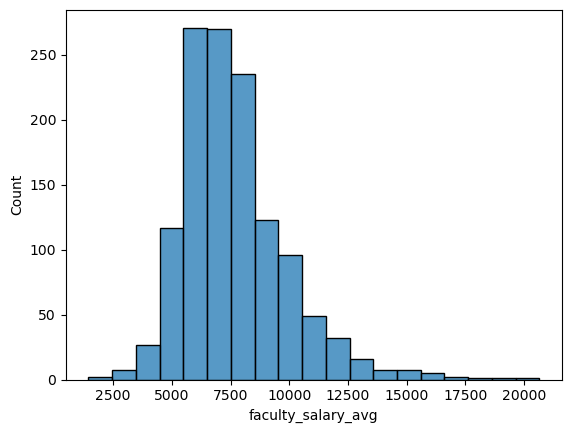

In [14]:
#exclude outliers 
#identify outliers with a barchart 
sns.histplot(data=df, x='faculty_salary_avg', binwidth=1000)

In [15]:
#exclude outliers 
df2=df[df['faculty_salary_avg'] < 20000]

In [16]:
df2

,id,name,city,state,region,highest_degree,control,gender,admission_rate,sat_avg,undergrads,tuition,faculty_salary_avg,loan_default_rate,median_debt,lon,lat
0,102669,Alaska Pacific University,Anchorage,AK,West,Graduate,Private,CoEd,0.4207,1054,275,19610,5804,0.077,23250.0,-149.900278,61.218056
1,101648,Marion Military Institute,Marion,AL,South,Associate,Public,CoEd,0.6139,1055,433,8778,5916,0.136,11500.0,-87.319165,32.632354
2,100830,Auburn University at Montgomery,Montgomery,AL,South,Graduate,Public,CoEd,0.8017,1009,4304,9080,7255,0.106,21335.0,-86.299969,32.366805
3,101879,University of North Alabama,Florence,AL,South,Graduate,Public,CoEd,0.6788,1029,5485,7412,7424,0.111,21500.0,-87.677251,34.799810
4,100858,Auburn University,Auburn,AL,South,Graduate,Public,CoEd,0.8347,1215,20514,10200,9487,0.045,21831.0,-85.480782,32.609857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1264,237385,Glenville State College,Glenville,WV,South,Bachelor,Public,CoEd,0.4656,900,1378,6696,6399,0.230,26000.0,-80.837603,38.934257
1265,237118,Alderson Broaddus University,Philippi,WV,South,Graduate,Private,CoEd,0.4258,990,1024,22740,4964,0.073,27000.0,-80.040358,39.152320
1266,238078,Wheeling Jesuit University,Wheeling,WV,South,Graduate,Private,CoEd,0.6263,1032,1131,28030,5917,0.031,27000.0,-80.720915,40.063962
1267,237181,Bethany College,Bethany,WV,South,Graduate,Private,CoEd,0.6205,906,716,25736,5758,0.171,28549.5,-80.556738,40.205627


In [17]:
#students sat greater than 1500 or less than 500 
df3 = df[(df['sat_avg'] > 1500) | (df['sat_avg'] < 500)]
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 48 to 421
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  3 non-null      int64   
 1   name                3 non-null      object  
 2   city                3 non-null      object  
 3   state               3 non-null      object  
 4   region              3 non-null      category
 5   highest_degree      3 non-null      category
 6   control             3 non-null      category
 7   gender              3 non-null      category
 8   admission_rate      3 non-null      float64 
 9   sat_avg             3 non-null      int64   
 10  undergrads          3 non-null      int64   
 11  tuition             3 non-null      int64   
 12  faculty_salary_avg  3 non-null      int64   
 13  loan_default_rate   3 non-null      float64 
 14  median_debt         3 non-null      float64 
 15  lon                 3 non-null      float64 
 

In [18]:
#extact the analyzed data to csv
df3.to_csv('data/outliers.csv')